In [6]:
#Q1. Data Loading & Understanding

import pandas as pd
df = pd.read_csv('loan_approval.csv')

df.head()          # a) first 5 rows
df.shape            # c) shape
df.dtypes           # d) data types

name              object
city              object
income             int64
credit_score       int64
loan_amount        int64
years_employed     int64
points             int64
loan_approved       bool
dtype: object

In [2]:
#Q2. Data Cleaning

df.isnull().sum()              # a) check missing

name              0
city              0
income            0
credit_score      0
loan_amount       0
years_employed    0
points            0
loan_approved     0
dtype: int64

In [3]:
# c) categorical columns
categorical_cols = df.select_dtypes(include='object').columns
print(categorical_cols)

Index(['name', 'city'], dtype='object')


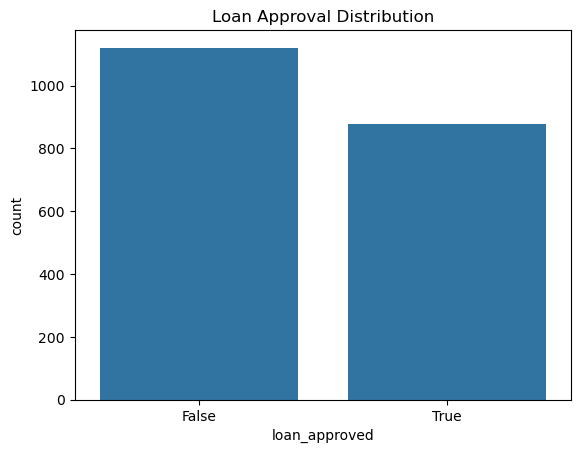

In [4]:
#Q3. EDA

import seaborn as sns
import matplotlib.pyplot as plt

# a) target distribution
sns.countplot(data=df, x='loan_approved')
plt.title('Loan Approval Distribution')
plt.show()

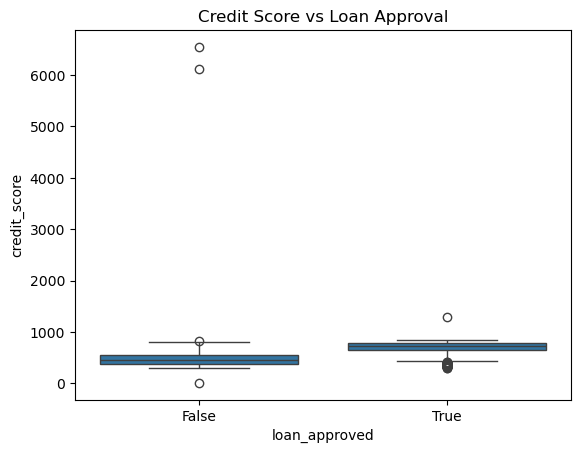

In [5]:
# b) numerical feature vs target (credit_score)
sns.boxplot(data=df, x='loan_approved', y='credit_score')
plt.title('Credit Score vs Loan Approval')
plt.show()

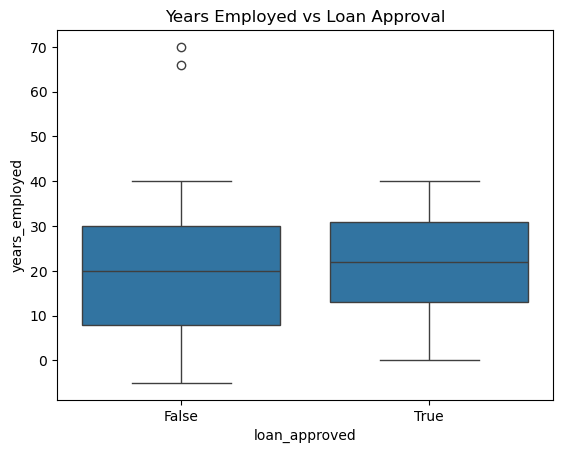

In [6]:
# c) years_employed vs target
sns.boxplot(data=df, x='loan_approved', y='years_employed')
plt.title('Years Employed vs Loan Approval')
plt.show()

In [8]:
#Q4. Outlier Detection & Treatment (IQR method)

for col in ['income','credit_score','loan_amount','years_employed','points']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = df[(df[col]<lower)|(df[col]>upper)]
    print(col, "outliers:", len(outliers))

income outliers: 0
credit_score outliers: 3
loan_amount outliers: 0
years_employed outliers: 2
points outliers: 0


In [11]:
for col in ['income','credit_score','loan_amount','years_employed','points']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    df[col] = df[col].clip(lower, upper)

In [13]:
#Q5. Convert target to numeric & drop unnecessary columns

df['loan_approved'] = df['loan_approved'].astype(int)   # True/False -> 1/0
df = df.drop(['name', 'city'], axis=1, errors='ignore')  # not useful for prediction

In [16]:
#Q6. Feature Selection & Data Splitting

from sklearn.model_selection import train_test_split

X = df.drop('loan_approved', axis=1)
y = df['loan_approved']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [17]:
#Q7. Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
#Q8. Logistic Regression Model Building

from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

In [20]:
#Q9. Confusion Matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[224   0]
 [  0 176]]


In [22]:
import matplotlib.pyplot as plt

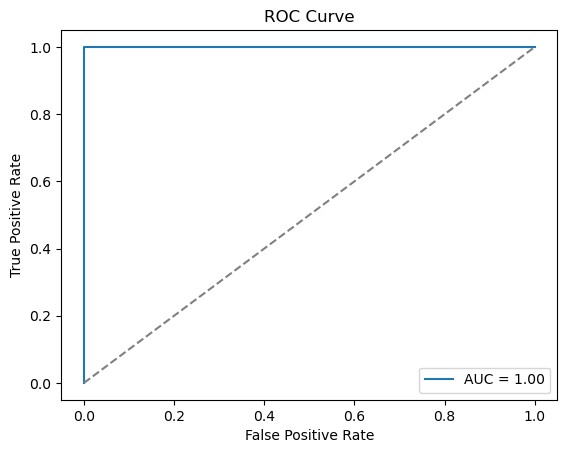

AUC Score: 1.0


In [23]:
#Q10. ROC Curve & AUC

from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test_scaled)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0,1],[0,1],'--', color='gray')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

print("AUC Score:", auc)